In [1]:
import os
import numpy as np
from tqdm import tqdm
import pandas as pd
import random
import sys


# pytorch
sys.path.append('/home/agustin/phd/miccai/miccai_2026/mri_x_fields/experiments/utils')
sys.path.append('/home/agustin/phd/synthesis')

import utils.nifti_functions as nfc
import utils.functions as fc
import utils.util_freesurfer_segmentation as ufs

import prep_image as prep_image
# from scipy.ndimage import zoom

In [ ]:
# def merge_segmentation(seg, mapping_dict):
#     """
#     Merges the segmentation labels according to the provided mapping dictionary.

#     Parameters:
#     seg (numpy.ndarray): The input segmentation array.
#     mapping_dict (dict): A dictionary where keys are the new label values and values are lists of old label values to be merged.
#         e.g: {
#             1: [10, 11, 12],  # Merge labels 10, 11, and 12 into new label 1
#             2: [20, 21],      # Merge labels 20 and 21 into new label 2
#             ...
#         }

#     Returns:
#     numpy.ndarray: The merged segmentation array.
#     """
#     merged_segmentation = np.zeros_like(seg) 
    
#     for new_label, old_labels in mapping_dict.items():
#         for old_label in old_labels:
#             merged_segmentation[seg == old_label] = new_label
            
#     return merged_segmentation


# "surrounding_csf_vol", 
# "cortical_gm_vol", 
# "cerebral_wm_vol", 
# "ventricles" : "lateral_ventricles_vol", "third_ventricle_vol", "fourth_ventricle_vol", "inferior_lateral_ventricles"
# "sub_cortial_structures: "thalamus_vol", "hippocampus_vol", "amygdala_vol", "putamen_vol", "pallidum_vol", "caudate_vol", "accumbens_area_vol", "ventral_dc_vol",
# "cerebellum_gm_vol", 
# "cerebellum_wm_vol", 
# "brainstem_vol"




mapping_dict_8 = {
    1: ufs.SURROUNDING_CSF,    
    2: ufs.CEREBRAL_CORTEX_36,
    3: ufs.CEREBRAL_WM + ufs.EXTRA_CEREBRAL_WM,
    4: ufs.INTERNAL_CSF,
    5: ufs.CEREBRAL_SUB_CORTICAL_GM + ufs.EXTRA_CEREBRAL_SUB_CORTICAL_GM,
    6: ufs.CEREBELLUM_GM,
    7: ufs.CEREBELLUM_WM,
    8: ufs.BRAINSTEM
}

seg, aff = nfc.load_nifti('/home/agustin/phd/miccai/miccai_2026/mri_x_fields/data/pr_train_data/preprocessed/supersynth/T1W/7.0T/SP_T1W_7T_0006/segmentation_resampled.nii.gz')  

seg_8 = ufs.merge_segmentation(seg, mapping_dict_8)
seg_3 = ufs.merge_seg36_to_seg3(seg)
# fc.imgshow_3D_list([seg_8], moving_plane=0)

# fc.imgshow_3D(seg)

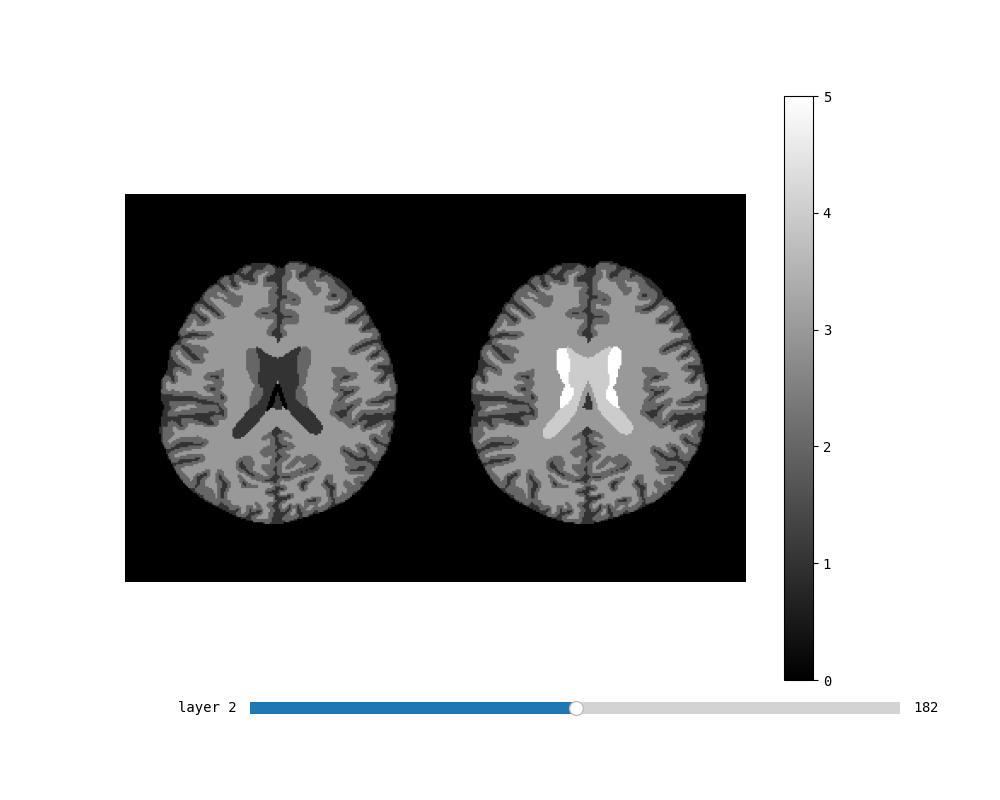

In [8]:
fc.imgshow_3D_list([seg_3,seg_8], moving_plane=2)
# fc.imgshow_3D_list([seg_3,seg_8], moving_plane=0)


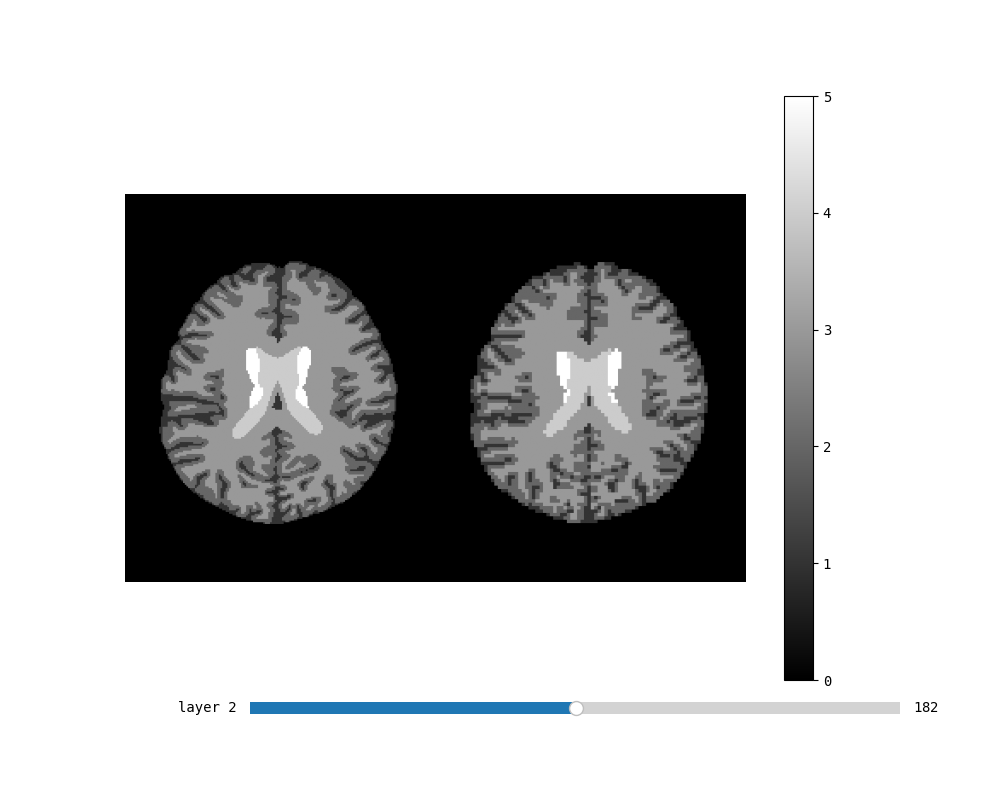

In [9]:
import prep_image as prep_image
from scipy.ndimage import zoom

%matplotlib widget

_seg_8 = prep_image.prepare_img(seg_8, normalize=False)
seg_small = zoom(_seg_8, (0.25, 0.25, 0.25), order=0)
seg_back = zoom(seg_small, (4, 4, 4), order=0)

seg_back = prep_image.resize_center_crop_pad(seg_back, seg_8.shape)[0]
fc.imgshow_3D_list([seg_8, seg_back], moving_plane=2)


(array([914., 915.]), array([1552,    8]))
Layer with most missing voxels in seg_8: 218, with 80 voxels not included.


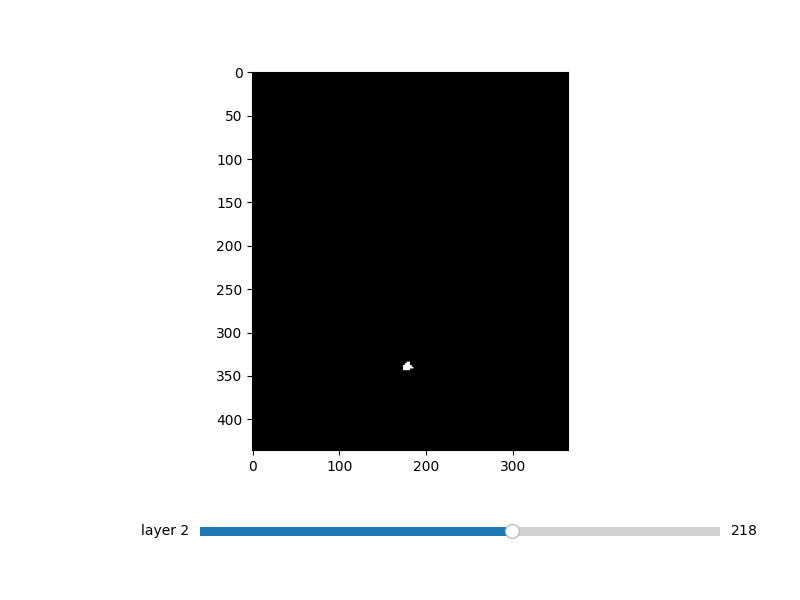

In [4]:
mask_seg = np.where(seg > 0, 1, 0)
mask_8 = np.where(seg_8 > 0, 1, 0)

not_in_mask_8 = np.where((mask_seg == 1) & (mask_8 == 0), 1, 0)
print(np.unique(seg[not_in_mask_8 == 1], return_counts=True))

# find the layer with the most voxels not included in seg_8
layer_counts = np.sum(not_in_mask_8, axis=(0, 1))
most_missing_layer = np.argmax(layer_counts)
print(f"Layer with most missing voxels in seg_8: {most_missing_layer}, with {layer_counts[most_missing_layer]} voxels not included.")

# print(np.sum(np.where(seg == 0, 1, 0)))
# print(np.sum(np.where(seg_8 == 0, 1, 0)))
# print(np.sum(np.where(seg == 0, 1, 0)) == np.sum(np.where(seg_8 == 0, 1, 0)))

# seg_8_inverse = np.where(seg_8 == 0, 1, 0)
%matplotlib widget
# seg_3 = ufs.merge_seg36_to_seg3(seg)
# fc.imgshow_3D_list([seg, seg_3, seg_8])
# fc.imgshow_3D_list([seg_3, seg_8])
fc.imgshow_3D(not_in_mask_8, current_plane=most_missing_layer)
